# Exploratory Data Analysis (EDA)
## Project Overview

This notebook performs an exploratory data analysis of the France Top 50 Spotify Playlist to identify patterns in explicit content, release formats, album structure, song duration, and playlist rankings. The insights generated will support Atlantic Recording Corporation in understanding audience preferences and optimizing music release strategies.

## Section 1: Explicit Content Analysis

### Objective

The objective of this analysis is to understand the presence and performance of explicit songs in the France Top 50 Playlist. The findings will help Atlantic Recording Corporation understand audience sensitivity toward explicit content and support decisions regarding content compliance and release strategy.

In [352]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [353]:
df = pd.read_csv("../data/france_top50_cleaned.csv")
print("Shape of dataset :",df.shape)
df.head()

Shape of dataset : (27780, 11)


,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url,duration_minutes
0,2024-05-18,1,LA RUE,No Limit & Gazo & Damso,72,225137,single,1,True,https://i.scdn.co/image/ab67616d0000b27384f245...,3.75
1,2024-05-18,2,C'est carré le S,Naps,74,201533,album,22,False,https://i.scdn.co/image/ab67616d0000b27348f7c1...,3.36
2,2024-05-18,3,Freestyle LVL UP 1,Ninho,76,114182,single,1,True,https://i.scdn.co/image/ab67616d0000b273fbe613...,1.90
3,2024-05-18,4,Bolide allemand,SDM,79,176746,album,15,True,https://i.scdn.co/image/ab67616d0000b273455e89...,2.95
4,2024-05-18,5,Freestyle LVL UP 2,Ninho,71,149064,single,1,True,https://i.scdn.co/image/ab67616d0000b27351f1cb...,2.48


## 1.1 Explicit Content Distribution

**Objective:** Analyze the distribution of Explicit and Clean songs in the playlist.

In [354]:
explicit_count = df["is_explicit"].value_counts()
explicit_count

is_explicit
True     15629
False    12151
Name: count, dtype: int64

## 1.2 Explicit Content Percentage

**Objective:** Calculate the percentage of Explicit and Clean songs.

In [355]:
explicit_percentage = (df["is_explicit"].value_counts(normalize=True)*100).round(2)
explicit_percentage

is_explicit
True     56.26
False    43.74
Name: proportion, dtype: float64

## 1.3 Explicit Content Visualization

**Objective:** Visualize the distribution of Explicit and Clean songs.

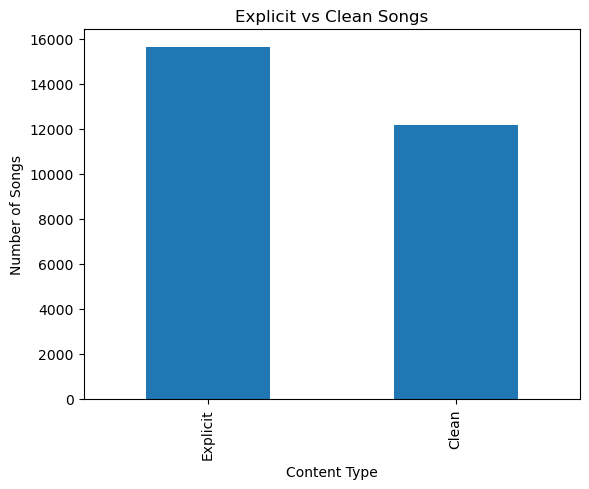

In [356]:
# Bar chart for explicit vs clean songs

df["content_type"] = df["is_explicit"].map({
    True:"Explicit",
    False:"Clean"
})
explicit_percentage = (df["content_type"].value_counts(normalize=True)*100).round(2) # For better understanding
explicit_count = df["content_type"].value_counts() # For better understanding

explicit_count.plot(kind='bar')
plt.title("Explicit vs Clean Songs")
plt.xlabel("Content Type")
plt.ylabel("Number of Songs")
plt.show()

## 1.4 Explicit Content Share

**Objective:** Visualize the percentage share of Explicit and Clean songs.

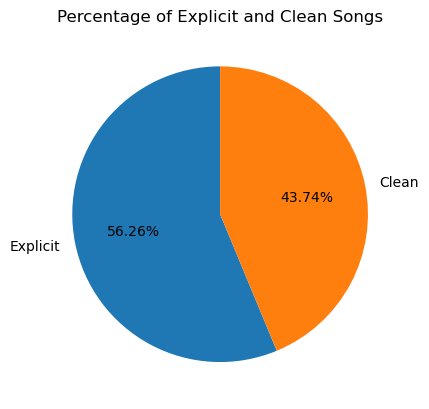

In [357]:
# Pie Chart for Explicit vs Clean Songs

explicit_percentage.plot(kind='pie',autopct="%1.2f%%" ,startangle=90)
plt.title("Percentage of Explicit and Clean Songs")
plt.ylabel("")
plt.show()

### Observation

- Explicit songs account for a larger share of the playlist than Clean songs.
- More than half of the playlist entries are Explicit.

# Section 2: Popularity Analysis

## 2.1 Average Popularity by Content Type

**Objective:** Compare the average popularity of Explicit and Clean songs.

In [358]:
# Average popularity of Explicit and Clean songs

popularity_analysis = df.groupby("content_type")["popularity"].mean().round(2)
popularity_analysis

content_type
Clean       80.91
Explicit    73.33
Name: popularity, dtype: float64

### Observation

- Clean songs have a higher average popularity score (80.91) than Explicit songs (73.33).
- Although Explicit songs appear more frequently in the playlist, Clean songs perform better on average in terms of popularity.

## 2.2 Popularity Comparison

**Objective:** Visualize the average popularity of Explicit and Clean songs.

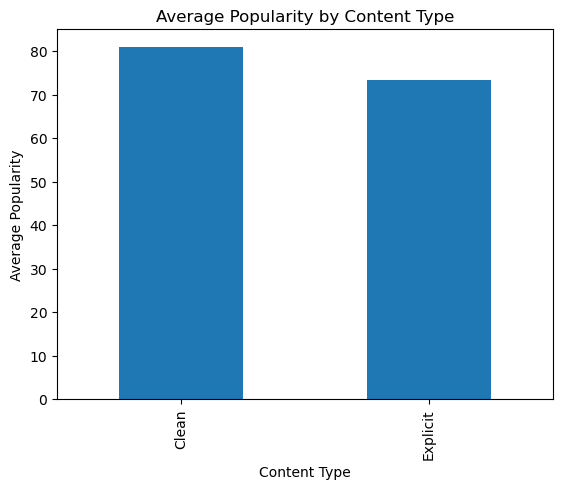

In [359]:
# Bar Chart for Average Popularity

popularity_analysis.plot(kind="bar")

plt.title("Average Popularity by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Average Popularity")

plt.show()

## 2.3 Popularity Distribution

**Objective:** Analyze the distribution of song popularity.

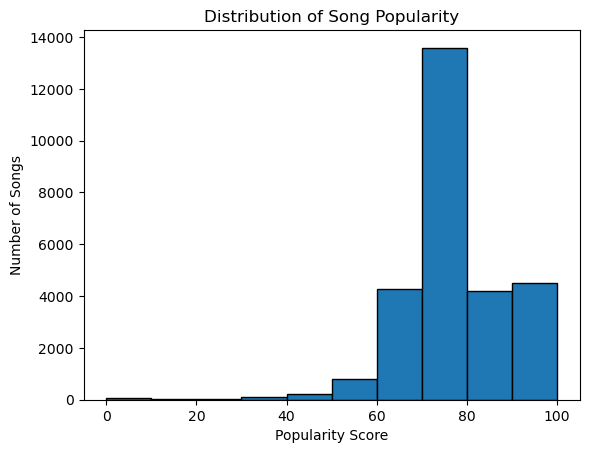

In [360]:
# Distribution of Song Popularity

df["popularity"].plot(kind="hist",bins=10,edgecolor="black")
plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity Score")
plt.ylabel("Number of Songs")
plt.show()

## 2.4 Popularity Distribution by Content Type

**Objective:** Compare the spread of popularity scores for Explicit and Clean songs.

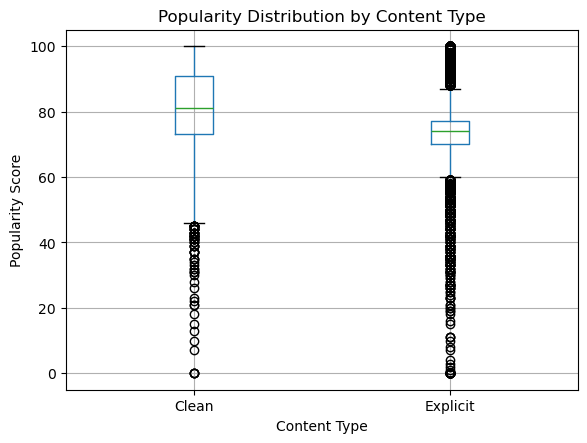

In [361]:
# Box Plot of Popularity by Content Type

df.boxplot(column="popularity",by="content_type")
plt.title("Popularity Distribution by Content Type")
plt.suptitle("")
plt.xlabel("Content Type")
plt.ylabel("Popularity Score")
plt.show()

### Observation

- Clean songs have a higher median popularity than Explicit songs.
- The popularity of Clean songs is more spread out, indicating greater variation.
- Both content types contain several outliers, showing that some songs perform significantly better or worse than the majority.
- Although Explicit songs are more common in the playlist, Clean songs generally achieve higher popularity scores.

# Section 3: Song Duration Analysis

## Objective

Analyze song duration to understand the preferred song length in the France Top 50 Playlist.

## 3.1 Summary Statistics

**Objective:** Summarize the overall duration of songs.

In [362]:
df["duration_minutes"].describe()

count    27780.000000
mean         3.091248
std          0.540215
min          0.670000
25%          2.760000
50%          3.000000
75%          3.460000
max          9.120000
Name: duration_minutes, dtype: float64

## 3.2 Duration Distribution

**Objective:** Analyze the distribution of song durations across the playlist.

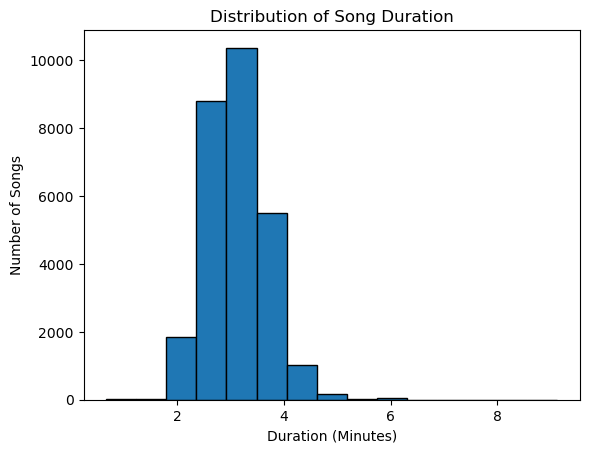

In [363]:
# Histogram of Song Duration

df["duration_minutes"].plot(kind="hist",bins=15,edgecolor="black")
plt.title("Distribution of Song Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Songs")
plt.show()

### Observation

- Most songs are concentrated between **2.5 and 3.5 minutes**.
- Very short songs (less than 2 minutes) and very long songs (more than 5 minutes) are uncommon.
- The distribution is slightly **right-skewed**, indicating a small number of longer songs.
- This suggests that the France Top 50 playlist primarily consists of songs with durations close to **3 minutes**.

## 3.3 Duration by Content Type

**Objective:** Compare the duration of Explicit and Clean songs to identify whether content type influences song length.

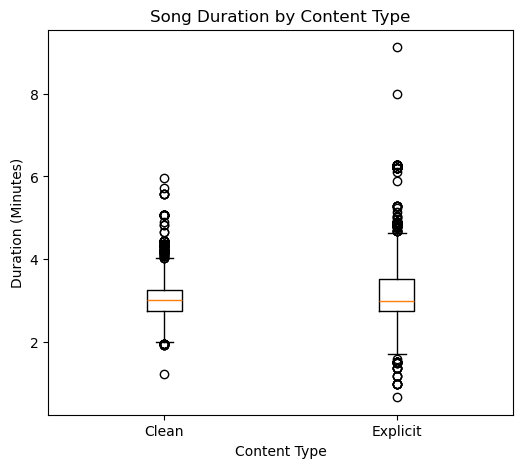

In [364]:
plt.figure(figsize=(6,5))
plt.boxplot([
    df[df["content_type"]=="Clean"]["duration_minutes"],
    df[df["content_type"]=="Explicit"]["duration_minutes"]
])
plt.xticks([1,2],["Clean","Explicit"])
plt.title("Song Duration by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Duration (Minutes)")
plt.show()

### Observation

- The median duration of Clean and Explicit songs is approximately **3 minutes**.
- Explicit songs show slightly greater variation in duration than Clean songs.
- Both content types contain several outliers, indicating the presence of unusually short and long songs.
- Explicit songs include the longest tracks in the dataset, with some exceeding **8 minutes**.

## 3.4 Duration Buckets

**Objective:** Categorize songs into Short, Medium, and Long durations to identify the most common song length in the France Top 50 playlist.

In [365]:
df["duration_bucket"] = pd.cut(
    df["duration_minutes"],
    bins=[0,2.5,3.5,float("inf")],
    labels=["Short","Medium","Long"]
)

In [366]:
df["duration_bucket"].value_counts()

duration_bucket
Medium    17707
Long       6477
Short      3596
Name: count, dtype: int64

In [367]:
duration_percentage = (df["duration_bucket"].value_counts(normalize=True).mul(100).round(2))
duration_percentage

duration_bucket
Medium    63.74
Long      23.32
Short     12.94
Name: proportion, dtype: float64

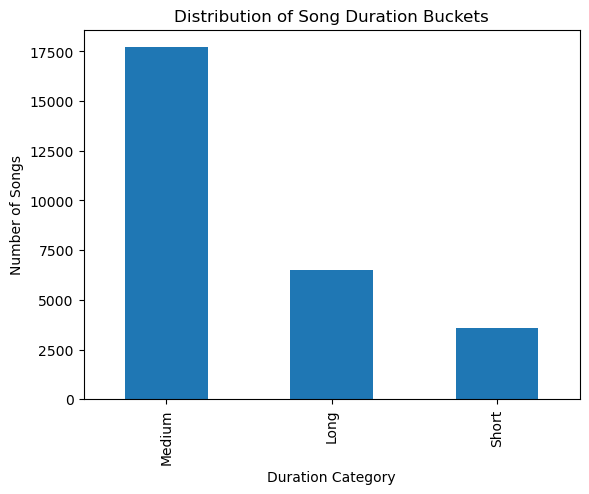

In [368]:
duration_counts = df["duration_bucket"].value_counts()
duration_counts.plot(kind="bar")
plt.title("Distribution of Song Duration Buckets")
plt.xlabel("Duration Category")
plt.ylabel("Number of Songs")
plt.show()

### Observation

- Medium-duration songs (2.5–3.5 minutes) dominate the France Top 50 playlist, accounting for **63.74%** of all songs.
- Long-duration songs (>3.5 minutes) represent **23.32%** of the playlist.
- Short songs (<2.5 minutes) are the least common, making up only **12.94%** of the dataset.
- This suggests that songs around **3 minutes** are the preferred duration in the France Top 50 playlist.

## 3.5 Duration vs Popularity

**Objective:** Analyze whether song duration has any relationship with popularity by comparing the average popularity score across different duration categories.

In [369]:
duration_popularity = df.groupby("duration_bucket")["popularity"].mean().round(2)
duration_popularity

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_26140\4226332099.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  duration_popularity = df.groupby("duration_bucket")["popularity"].mean().round(2)


duration_bucket
Short     76.85
Medium    75.75
Long      78.98
Name: popularity, dtype: float64

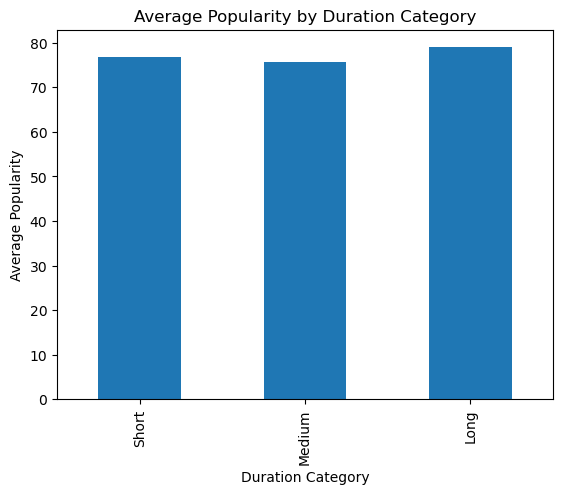

In [370]:
duration_popularity.plot(kind="bar")

plt.title("Average Popularity by Duration Category")
plt.xlabel("Duration Category")
plt.ylabel("Average Popularity")

plt.show()

### Observation

- Long-duration songs have the highest average popularity score (**78.98**), followed by short-duration songs (**76.85**).
- Medium-duration songs, despite being the most common in the playlist, have the lowest average popularity (**75.75**).
- The differences in popularity are relatively small, suggesting that song duration alone does not strongly determine popularity.

# Section 4: Release Format Preference Analysis

## Objective

Analyze the representation and performance of Singles and Album tracks in the France Top 50 Playlist to understand audience preferences for different release formats.

## 4.1 Release Format Distribution

### Objective

Analyze the distribution of Singles and Album tracks in the France Top 50 Playlist.

In [371]:
release_df = df[df["album_type"].isin(["album","single"])]


In [372]:
album_count = release_df["album_type"].value_counts()
album_count

album_type
album     14686
single    13085
Name: count, dtype: int64

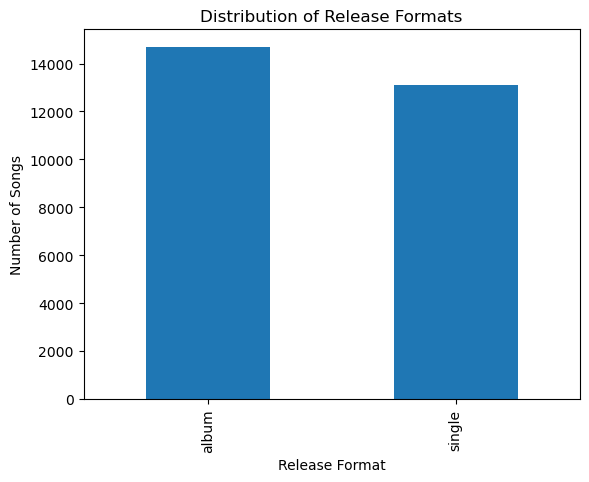

In [373]:
album_count.plot(kind="bar")

plt.title("Distribution of Release Formats")
plt.xlabel("Release Format")
plt.ylabel("Number of Songs")

plt.show()

### Observation

- Album tracks appear slightly more frequently than singles in the France Top 50 Playlist.
- Both release formats have a strong presence, indicating that listeners engage with both standalone singles and album releases.
- The difference is relatively small, suggesting a balanced distribution between the two release formats.

## 4.2 Release Format Percentage

### Objective

Calculate the percentage share of each release format in the France Top 50 Playlist.

In [374]:
album_percentage = (
    release_df["album_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

album_percentage

album_type
album     52.88
single    47.12
Name: proportion, dtype: float64

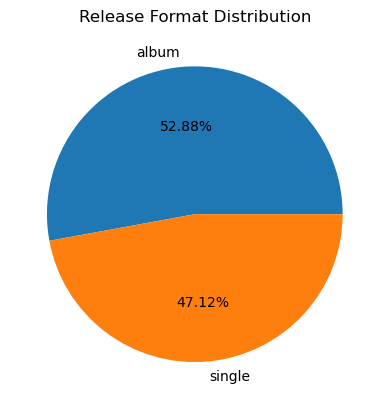

In [375]:
album_percentage.plot(
    kind="pie",
    autopct="%1.2f%%"
)

plt.title("Release Format Distribution")
plt.ylabel("")

plt.show()

## 4.3 Popularity by Release Format

### Objective

Compare the average popularity of album tracks and singles to determine which release format performs better in the France Top 50 Playlist.

In [376]:
format_popularity = (
    release_df.groupby("album_type")["popularity"]
    .mean()
    .round(2)
)
format_popularity

album_type
album     72.99
single    80.75
Name: popularity, dtype: float64

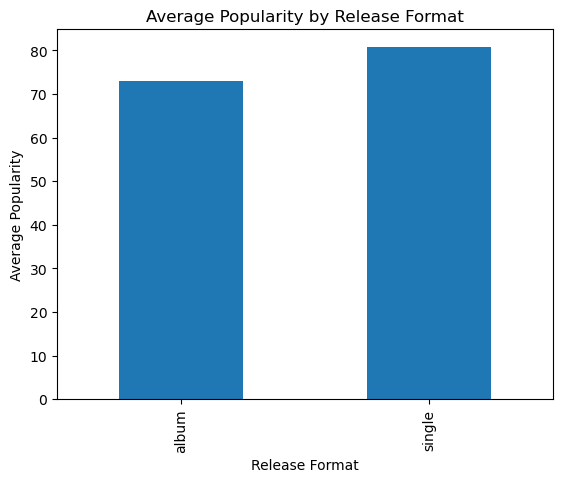

In [377]:
format_popularity.plot(kind="bar")
plt.title("Average Popularity by Release Format")
plt.xlabel("Release Format")
plt.ylabel("Average Popularity")
plt.show()

## 4.4 Rank-based Release Format Comparison

### Objective

Analyze how album tracks and singles are distributed across playlist positions to identify whether one release format performs better at higher ranks.

In [378]:
rank_format = ( release_df.groupby("album_type")["position"].mean().round(2) )
rank_format

album_type
album     26.73
single    24.13
Name: position, dtype: float64

### Observation

- Singles have a lower average playlist position (**24.13**) than album tracks (**26.73**).
- Since lower playlist positions indicate better rankings, singles generally perform better in the France Top 50 Playlist.
- Although album tracks are slightly more common in the playlist, singles tend to achieve higher rankings on average.

# Section 5: Album Structure Impact Analysis

## Objective

Analyze how album size influences song popularity and determine whether larger albums perform differently from smaller albums in the France Top 50 Playlist.

## 5.1 Album Size Distribution

### Objective

Analyze the distribution of the total number of tracks in albums represented in the France Top 50 Playlist.

In [379]:
release_df["total_tracks"].describe()

count    27771.000000
mean         8.987901
std          8.060757
min          1.000000
25%          1.000000
50%         10.000000
75%         15.000000
max         40.000000
Name: total_tracks, dtype: float64

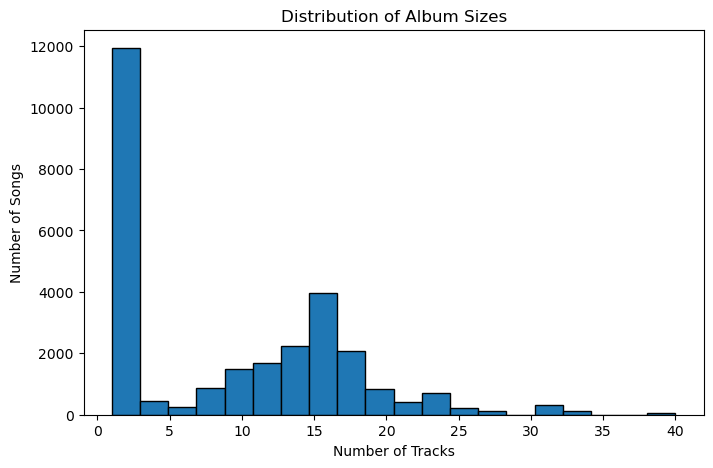

In [380]:
plt.figure(figsize=(8,5))

plt.hist(release_df["total_tracks"], bins=20,edgecolor="black" )

plt.title("Distribution of Album Sizes")
plt.xlabel("Number of Tracks")
plt.ylabel("Number of Songs")

plt.show()

In [381]:
release_df["total_tracks"].value_counts().head(10)

total_tracks
1     11325
15     2697
10     1471
17     1452
14     1341
16     1264
12     1079
13      896
19      690
23      680
Name: count, dtype: int64

### Observation

- Albums containing **1 track** are the most common in the dataset, representing standalone single releases.
- Among multi-track albums, releases with **10–17 tracks** are the most frequently represented.
- Very large albums contribute relatively fewer songs, indicating that medium-sized albums are more common in the France Top 50 Playlist.

## 5.2 Album Size vs Popularity

### Objective

Analyze whether the number of tracks in an album influences the popularity of songs in the France Top 50 Playlist.

In [382]:
album_popularity = (
    release_df.groupby("total_tracks")["popularity"]
    .mean()
    .round(2)
)
album_popularity.head(10)

total_tracks
1     80.83
2     85.98
3     83.08
4     76.34
5     73.42
6     68.10
7     70.66
8     69.08
9     64.83
10    81.06
Name: popularity, dtype: float64

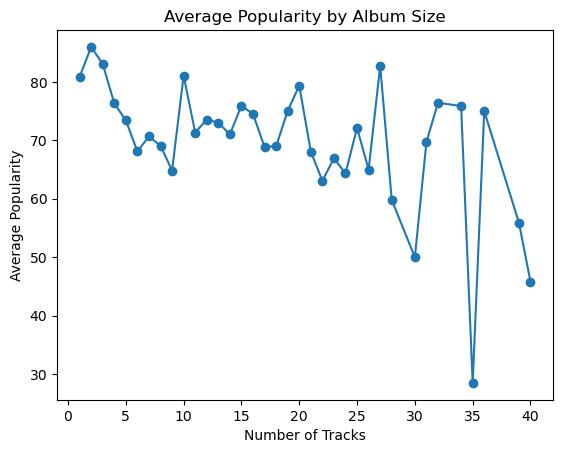

In [383]:
album_popularity.plot(kind="line", marker="o")

plt.title("Average Popularity by Album Size")
plt.xlabel("Number of Tracks")
plt.ylabel("Average Popularity")

plt.show()

### Observation

- Song popularity varies across different album sizes, with no consistent upward or downward trend.
- Smaller album sizes generally maintain high popularity, while some larger album sizes show greater fluctuations.
- These fluctuations are likely influenced by the small number of songs available for certain album sizes rather than album size alone.

## 5.3 Album Dilution vs Concentration Effect

### Objective

Analyze whether songs from small, medium, and large albums differ in popularity to determine if larger albums experience an album dilution effect.

In [384]:
release_df["album_size"] = pd.cut(
    release_df["total_tracks"],
    bins=[0, 10, 20, release_df["total_tracks"].max()],
    labels=["Small", "Medium", "Large"]
)

release_df[["total_tracks", "album_size"]].head()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_26140\2699129930.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  release_df["album_size"] = pd.cut(


,total_tracks,album_size
0,1,Small
1,22,Large
2,1,Small
3,15,Medium
4,1,Small


In [385]:
album_size_count = release_df["album_size"].value_counts()
album_size_count

album_size
Small     15007
Medium    10811
Large      1953
Name: count, dtype: int64

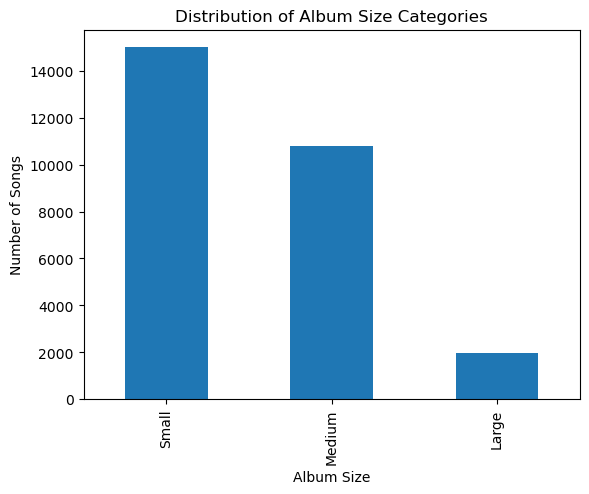

In [386]:
album_size_count.plot(kind="bar")
plt.title("Distribution of Album Size Categories")
plt.xlabel("Album Size")
plt.ylabel("Number of Songs")
plt.show()

### Observation

- Small albums (1–10 tracks) contribute the highest number of songs to the France Top 50 Playlist.
- Medium-sized albums (11–20 tracks) also have a substantial presence.
- Large albums (21+ tracks) are comparatively less represented, indicating that very large album releases are less common in the playlist.

### Popularity by Album Size Category

#### Objective

Compare the average popularity of songs released from small, medium, and large albums to determine whether album size influences song performance.

In [387]:
album_size_popularity = (
    release_df.groupby("album_size")["popularity"]
    .mean()
    .round(2)
)
album_size_popularity

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_26140\2612917390.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  release_df.groupby("album_size")["popularity"]


album_size
Small     80.28
Medium    73.05
Large     68.62
Name: popularity, dtype: float64

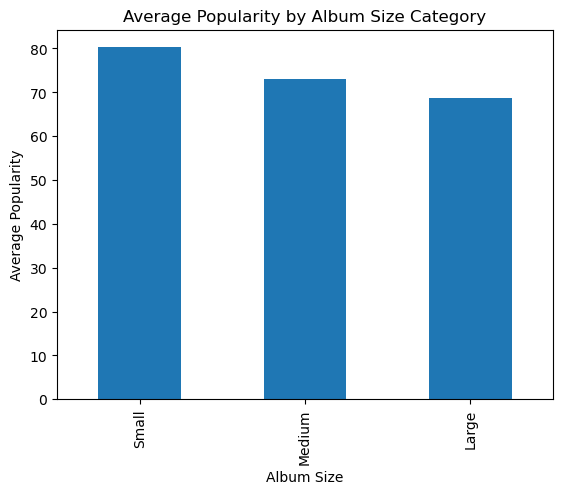

In [388]:
album_size_popularity.plot(kind="bar")
plt.title("Average Popularity by Album Size Category")
plt.xlabel("Album Size")
plt.ylabel("Average Popularity")
plt.show()

### Observation

- Songs released from **small albums (1–10 tracks)** have the highest average popularity (**80.28**).
- Average popularity decreases for **medium-sized albums (73.05)** and further declines for **large albums (68.62)**.
- This suggests a possible **album dilution effect**, where songs from larger albums are associated with lower average popularity than songs from smaller releases.

# Section 6: Content Attribute Concentration Analysis

## Objective

Analyze how different content attributes are distributed across the Top 10, Top 25, and Top 50 playlist positions to identify the characteristics of high-performing songs.

## 6.1 Explicit Content Concentration

### Objective

Analyze the proportion of explicit and clean songs within the Top 10, Top 25, and Top 50 playlist positions.

In [389]:
df["rank_group"] = pd.cut(
    df["position"],
    bins=[0, 10, 25, 50],
    labels=["Top 10", "Top 25", "Top 50"]
)
df[["position", "rank_group"]].head(15)

,position,rank_group
0,1,Top 10
1,2,Top 10
2,3,Top 10
3,4,Top 10
4,5,Top 10
5,6,Top 10
6,7,Top 10
7,8,Top 10
8,9,Top 10
9,10,Top 10


In [390]:
explicit_rank = pd.crosstab(
    df["rank_group"],
    df["content_type"],
    normalize="index"
).mul(100).round(2)
explicit_rank

content_type,Clean,Explicit
rank_group,,
Top 10,37.58,62.42
Top 25,45.46,54.54
Top 50,45.17,54.83


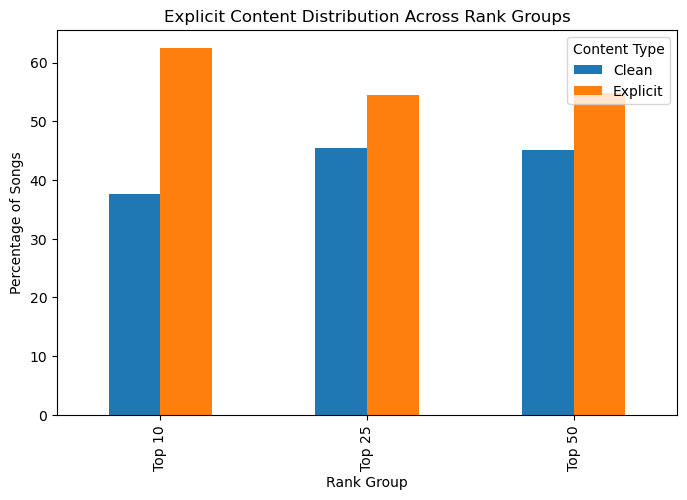

In [391]:
explicit_rank.plot(kind="bar", figsize=(8,5))
plt.title("Explicit Content Distribution Across Rank Groups")
plt.xlabel("Rank Group")
plt.ylabel("Percentage of Songs")
plt.legend(title="Content Type")
plt.show()

### Observation

- Explicit songs account for **62.42%** of the Top 10, making them the dominant content type among the highest-ranked tracks.
- In the Top 25 and Top 50, the share of explicit songs decreases to approximately **55%**, indicating a more balanced distribution.
- Overall, higher-ranked songs are associated with a greater proportion of explicit content in the France Top 50 Playlist.

## 6.2 Release Format Concentration

### Objective

Analyze the distribution of album tracks and singles across the Top 10, Top 25, and Top 50 playlist positions.

In [392]:

release_df = df[df["album_type"].isin(["album", "single"])]
release_rank = pd.crosstab(
    release_df["rank_group"],
    release_df["album_type"],
    normalize="index"
).mul(100).round(2)
release_rank

album_type,album,single
rank_group,,
Top 10,49.27,50.73
Top 25,48.85,51.15
Top 50,56.75,43.25


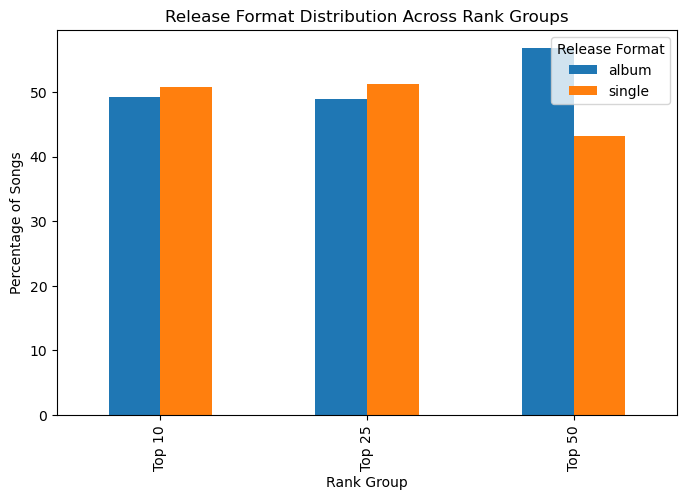

In [393]:
release_rank.plot(kind="bar", figsize=(8,5))
plt.title("Release Format Distribution Across Rank Groups")
plt.xlabel("Rank Group")
plt.ylabel("Percentage of Songs")
plt.legend(title="Release Format")
plt.show()

### Observation

- Singles represent a slightly higher proportion of songs in both the **Top 10 (50.73%)** and **Top 25 (51.15%)**.
- Album tracks become more dominant in the **Top 50 (56.75%)**.
- This suggests that singles are more strongly represented among the highest-ranked songs, while album tracks contribute more to the lower-ranked positions in the playlist.

## 6.3 Duration Category Concentration

### Objective

Analyze the distribution of short, medium, and long songs across the Top 10, Top 25, and Top 50 playlist positions.

In [394]:
duration_rank = pd.crosstab(
    df["rank_group"],
    df["duration_bucket"],
    normalize="index"
).mul(100).round(2)

duration_rank

duration_bucket,Short,Medium,Long
rank_group,,,
Top 10,11.42,65.57,23.01
Top 25,13.34,62.07,24.59
Top 50,13.32,64.01,22.67


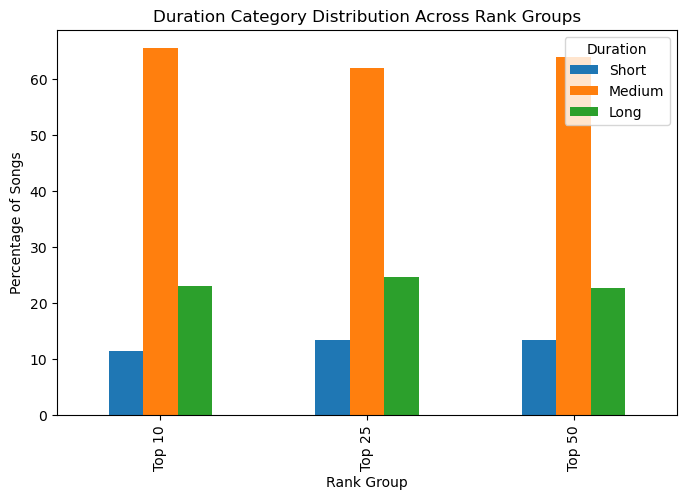

In [395]:
duration_rank.plot(kind="bar", figsize=(8,5))
plt.title("Duration Category Distribution Across Rank Groups")
plt.xlabel("Rank Group")
plt.ylabel("Percentage of Songs")
plt.legend(title="Duration")
plt.show()

### Observation

- Medium-duration songs dominate all rank groups, accounting for more than **62%** of songs in the Top 10, Top 25, and Top 50.
- Short-duration songs consistently represent the smallest share of the playlist.
- The distribution of duration categories remains relatively stable across all rank groups, suggesting that song duration has limited influence on playlist position.

## 6.4 Preferred Content Profile

### Objective

Summarize the key characteristics of high-performing songs in the France Top 50 Playlist based on the findings from the exploratory data analysis.

### Preferred Content Profile

Based on the exploratory data analysis, the typical high-performing song in the France Top 50 Playlist has the following characteristics:

- More likely to contain **explicit** content.
- More likely to be released as a **single**.
- Typically has a **medium duration** (2–4 minutes).
- Frequently comes from a **small album** (1–10 tracks).
- Achieves higher playlist positions compared to songs from larger albums.

## Business Recommendations

Based on the analysis, the following recommendations can help optimize music release strategies:

- Prioritize **single releases** for songs expected to achieve high playlist rankings.
- Consider releasing **smaller albums or EPs**, as songs from smaller releases are associated with higher average popularity.
- Maintain **medium song durations**, as they represent the majority of successful tracks.
- Explicit content has a strong presence among top-ranked songs; however, release decisions should balance audience reach, platform guidelines, and brand strategy.

# Dataset Validation Summary

### Daily Playlist Validation

To ensure the reliability of the analysis, the number of songs in each daily playlist snapshot was verified.

In [396]:
songs_per_day = df.groupby("date").size()
songs_per_day.value_counts()

50    553
49      1
81      1
Name: count, dtype: int64

In [397]:
songs_per_day = df.groupby("date").size()

songs_per_day[songs_per_day != 50]

date
2025-02-02    49
2025-03-01    81
dtype: int64

In [398]:
df[df["date"] == "2025-03-01"].duplicated().sum()

np.int64(0)

In [399]:
march1 = df[df["date"] == "2025-03-01"]

march1[march1["position"] == 4]

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url,duration_minutes,content_type,duration_bucket,rank_group
14352,2025-03-01,4,FLASHBACK,Favé,79,176120,album,15,True,https://i.scdn.co/image/ab67616d0000b273bed20c...,2.94,Explicit,Medium,Top 10
14399,2025-03-01,4,I love you,Dadju & Tayc,69,237866,album,16,False,https://i.scdn.co/image/ab67616d0000b273f0af4b...,3.96,Clean,Long,Top 10


In [400]:
df[df["date"] == "2025-03-01"]["position"].value_counts().sort_index()

position
1     1
2     1
3     1
4     2
5     2
6     1
7     1
8     1
9     2
10    2
11    1
12    1
13    2
14    2
15    1
16    1
17    1
18    2
19    1
20    2
21    2
22    2
23    2
24    2
25    2
26    2
27    2
28    2
29    2
30    1
31    2
32    2
33    2
34    2
35    2
36    2
37    2
38    2
39    1
40    2
41    2
42    1
43    1
44    1
45    1
46    2
47    2
48    2
49    1
50    2
Name: count, dtype: int64

In [401]:
march1[march1["position"] == 5]

,date,position,song,artist,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url,duration_minutes,content_type,duration_bucket,rank_group
14353,2025-03-01,5,I love you,Dadju & Tayc,69,237866,album,16,False,https://i.scdn.co/image/ab67616d0000b273f0af4b...,3.96,Clean,Long,Top 10
14400,2025-03-01,5,FLASHBACK,Favé,79,176120,album,15,True,https://i.scdn.co/image/ab67616d0000b273bed20c...,2.94,Explicit,Medium,Top 10


### Observation

- The dataset contains **553 daily playlist snapshots** with the expected **50 songs**.
- One playlist snapshot (**2025-02-02**) contains **49 songs**, indicating a single missing playlist entry.
- One playlist snapshot (**2025-03-01**) contains **81 songs** due to conflicting playlist entries where some songs appear with swapped playlist positions.
- Since these irregularities affect only **2 out of 555** daily snapshots, they are unlikely to materially influence the overall exploratory analysis and business insights.

### Dataset Limitation

The analysis is based on the provided Spotify playlist dataset. During validation, two daily playlist snapshots were found to contain irregular numbers of songs (49 and 81 instead of the expected 50). Investigation showed that the 81-song snapshot contains conflicting playlist entries with swapped positions rather than exact duplicate rows. As these inconsistencies affect only a very small proportion of the dataset, they were retained and documented instead of being manually modified to preserve the integrity of the original data source.

## Conclusion

This exploratory data analysis identified key patterns in explicit content, release format, album structure, and song duration within the France Top 50 Playlist. These findings provide a strong foundation for KPI analysis and the Power BI dashboard developed in the next phase of the project.